In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo profesional para las visualizaciones de la prueba
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """
    Carga el dataset de gasto en salud del Banco Mundial, 
    estandariza nombres de columnas a snake_case y maneja tambien metadatos.
    """
    # El archivo del Banco Mundial trae 4 filas de metadatos arriba; las saltamos con skiprows=4
    df = pd.read_csv(filepath, skiprows=4)
    
    # Estandarizar nombres de columnas a snake_case
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('/', '_')
        .str.replace('-', '_')
    )
    
    # Renombrar columnas clave para mayor claridad en el análisis de estos
    df = df.rename(columns={
        'country_name': 'country',
        'country_code': 'country_code'
    })
    
    return df

In [ ]:
import os

# Buscamos el archivo CSV que empieza con 'API_SH.XPD.CHEX' dentro de la carpeta data
data_dir = "../data"
csv_files = [f for f in os.listdir(data_dir) if f.startswith("API_SH.XPD.CHEX") and f.endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("¡Upps! No encontré el archivo CSV de datos en la carpeta /data/. Asegúrate de haberlo movido ahí.")

filepath = os.path.join(data_dir, csv_files[0])
print(f"Cargando archivo: {filepath}")

# Cargamos y limpiamos usando la función que definimos en la celda 1
df_health = load_and_clean_data(filepath)

# Mostramos las primeras 5 filas para verificar que todo esté en snake_case
df_health.head()

Cargando archivo: ../data\API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_33342.csv


,country,country_code,indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,unnamed:_70
0,Aruba,ABW,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,5.861513,5.727262,5.754125,5.985494,5.946320,5.566469,5.543797,NaN,NaN,NaN
2,Afghanistan,AFG,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,12.620817,14.208419,14.831320,15.533614,21.508444,23.088169,14.985763,NaN,NaN,NaN
3,Africa Western and Central,AFW,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,3.733106,3.288527,3.249834,3.788206,4.135655,4.174501,4.142601,NaN,NaN,NaN
4,Angola,AGO,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.437943,2.298875,2.203943,2.816889,2.739871,2.600410,2.546929,NaN,NaN,NaN


In [ ]:
# 1 Filtrar los datos de Guatemala
guatemala_data = df_health[df_health['country'].str.lower() == 'guatemala']

# 2 Identificar las columnas que representan años (son numéricas, ej. '1960', '2020')
year_cols = [col for col in df_health.columns if col.isdigit()]

# 3. Transponer para tener una serie temporal limpia y eliminar años sin datos
ts_guatemala = guatemala_data[year_cols].T
ts_guatemala.columns = ['value']
ts_guatemala.index = ts_guatemala.index.astype(int)
ts_guatemala = ts_guatemala.dropna()

# 4 Seleccionar los últimos 10 años disponibles
last_10_years = ts_guatemala.tail(10)
year_start = last_10_years.index[0]
year_end = last_10_years.index[-1]
n_years = len(last_10_years)

# 5 Calcular métricas
mean_val = last_10_years['value'].mean()
median_val = last_10_years['value'].median()

# Calcular CAGR (Tasa de Crecimiento Anual Compuesto)
v_initial = last_10_years['value'].iloc[0]
v_final = last_10_years['value'].iloc[-1]
cagr = (v_final / v_initial) ** (1 / (n_years - 1)) - 1 if v_initial > 0 else 0

# Imprimir resultados listos para tu reporte
print(f" MÉTRICAS DE GASTO EN SALUD PARA GUATEMALA ({year_start} - {year_end}) ")
print(f"Promedio: {mean_val:.3f}% del PIB")
print(f"Mediana:  {median_val:.3f}% del PIB")
print(f"CAGR:     {cagr * 100:.3f}% anual")

 MÉTRICAS DE GASTO EN SALUD PARA GUATEMALA (2014 - 2023) 
Promedio: 6.417% del PIB
Mediana:  6.155% del PIB
CAGR:     1.616% anual


In [ ]:
# 1 Lista de códigos del Banco Mundial que representan regiones y no países reales
region_codes = [
    'WLD', 'LMY', 'MIC', 'IBD', 'IBT', 'LMC', 'EAS', 'ECS', 'UMC', 'EAP', 
    'LTE', 'EMU', 'ECA', 'LAC', 'MEA', 'HIC', 'MNA', 'SAS', 'TSA', 'SSF',
    'TSS', 'PRE', 'IDA', 'IBRD', 'IDX', 'FCS', 'LAC', 'LCN', 'ECS'
]

# 2 Filtrar para quedarse solamente con países reales
df_countries = df_health[~df_health['country_code'].isin(region_codes)].copy()

# 3 Definir las columnas de los últimos 10 años que tienen datos consistentes (ej. 2012 a 2022)
# El dataset suele tener datos muy completos hasta 2022 o 2023. Por lo tanto, usare una ventana de 10 años
start_yr, end_yr = '2012', '2022'

# 4 Calcular crecimiento absoluto y relativo
df_countries['crecimiento_absoluto'] = df_countries[end_yr] - df_countries[start_yr]
df_countries['crecimiento_relativo'] = (df_countries[end_yr] - df_countries[start_yr]) / df_countries[start_yr]

# Eliminar nulos en las columnas calculadas para evitar distorsiones
df_countries = df_countries.dropna(subset=['crecimiento_absoluto', 'crecimiento_relativo'])

# 5 Encontrar el Top 10 manejando empates con el método 'min' 
df_countries['rank_abs'] = df_countries['crecimiento_absoluto'].rank(method='min', ascending=False)
df_countries['rank_rel'] = df_countries['crecimiento_relativo'].rank(method='min', ascending=False)

top_10_abs = df_countries[df_countries['rank_abs'] <= 10].sort_values(by='crecimiento_absoluto', ascending=False)
top_10_rel = df_countries[df_countries['rank_rel'] <= 10].sort_values(by='crecimiento_relativo', ascending=False)

print(f" TOP 10 PAÍSES CRECIMIENTO ABSOLUTO ({start_yr} - {end_yr}) ")
print(top_10_abs[['country', 'crecimiento_absoluto']].to_string(index=False))

 TOP 10 PAÍSES CRECIMIENTO ABSOLUTO (2012 - 2022) 
                 country  crecimiento_absoluto
             Afghanistan             15.191000
                  Naoero              9.500803
                  Tuvalu              7.414177
Central African Republic              6.031790
                 Liberia              5.958325
                Mongolia              4.993701
                   Palau              4.632330
             Yemen, Rep.              3.621699
                 Comoros              3.297649
              Mozambique              3.108324


C:\Users\Kellys\AppData\Local\Temp\ipykernel_19408\3646543786.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='crecimiento_absoluto', y='country', data=top_10_abs.head(10), palette='viridis')


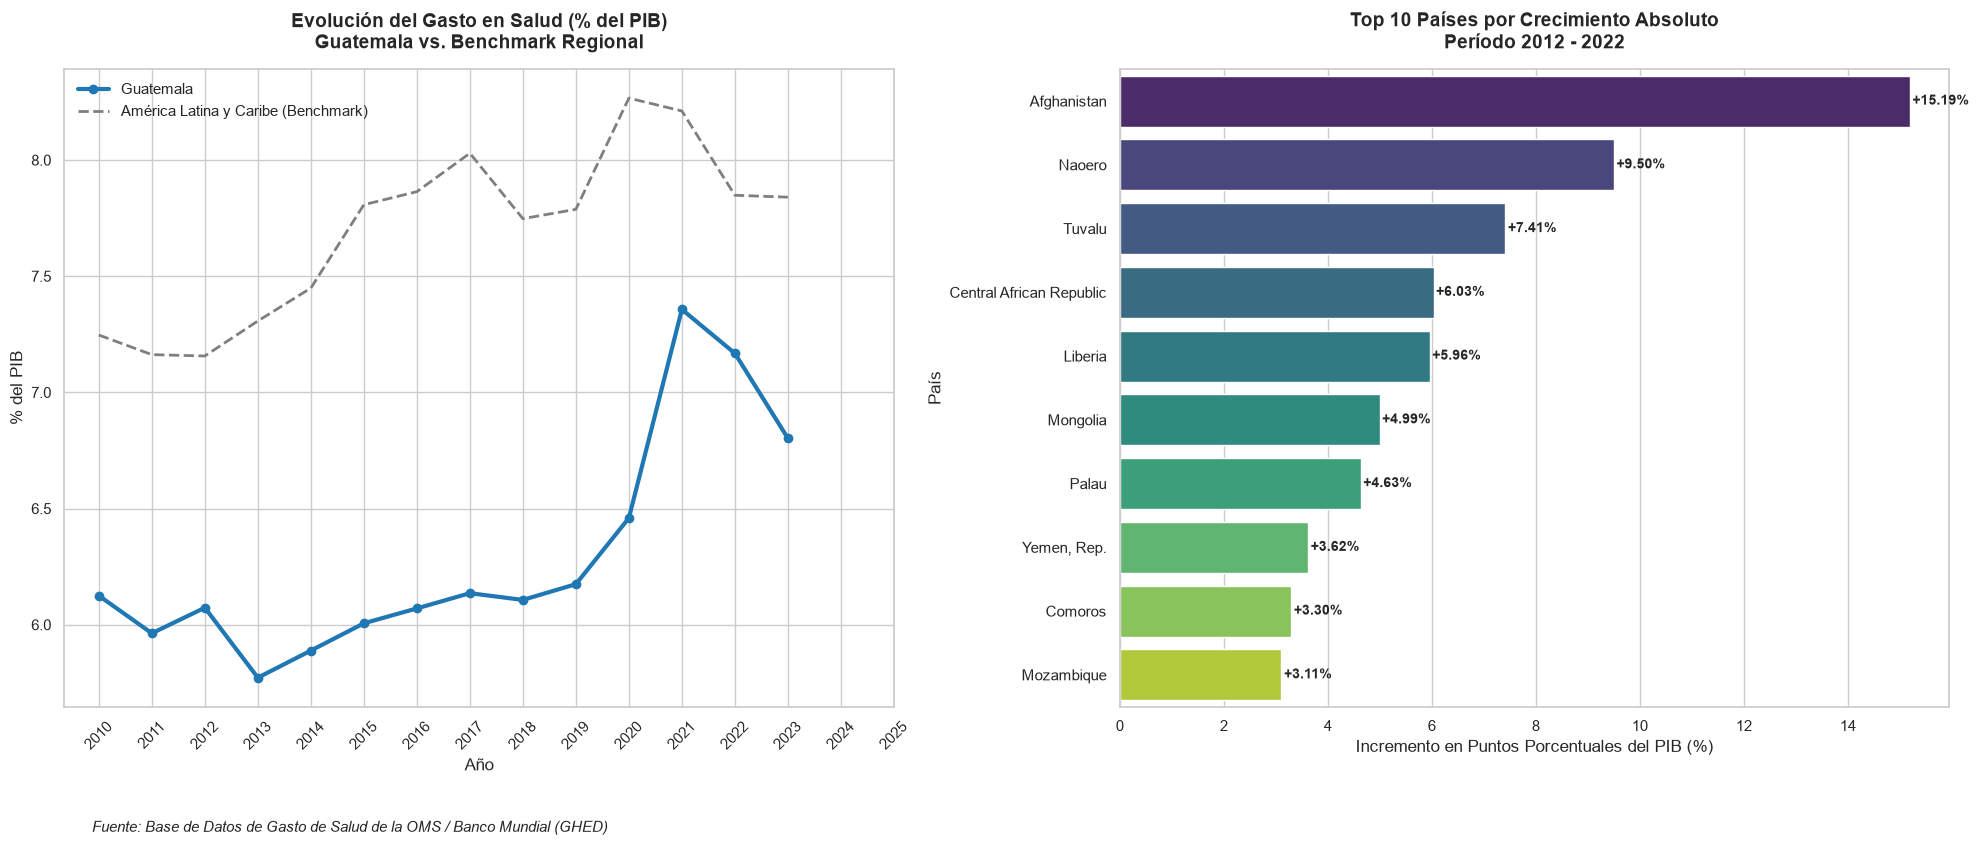

In [8]:
# Estilo y paleta
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# GRÁFICO 1: Serie Temporal Guatemala vs Benchmark Regional (América Latina)
years_int = [int(yr) for yr in year_cols if int(yr) >= 2010]
years_str = [str(yr) for yr in years_int]

# Extraer datos de Guatemala y del agregador regional de América Latina 
gt_series = df_health[df_health['country'].str.lower() == 'guatemala'][years_str].values.flatten()
latam_series = df_health[df_health['country_code'] == 'LAC'][years_str].values.flatten()

axes[0].plot(years_int, gt_series, marker='o', linewidth=3, color='#1f77b4', label='Guatemala')
axes[0].plot(years_int, latam_series, linestyle='--', linewidth=2, color='#7f7f7f', label='América Latina y Caribe (Benchmark)')
axes[0].set_title('Evolución del Gasto en Salud (% del PIB)\nGuatemala vs. Benchmark Regional', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Año', fontsize=12)
axes[0].set_ylabel('% del PIB', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].set_xticks(years_int)
axes[0].tick_params(axis='x', rotation=45)

#  GRÁFICO 2: Barras del Top 10 Crecimiento Absoluto
sns.barplot(ax=axes[1], x='crecimiento_absoluto', y='country', data=top_10_abs.head(10), palette='viridis')

# Etiquetas de datos al final de las barras
for index, value in enumerate(top_10_abs.head(10)['crecimiento_absoluto']):
    axes[1].text(value + 0.05, index, f"+{value:.2f}%", va='center', ha='left', fontweight='bold', fontsize=10)

axes[1].set_title(f'Top 10 Países por Crecimiento Absoluto\nPeríodo {start_yr} - {end_yr}', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Incremento en Puntos Porcentuales del PIB (%)', fontsize=12)
axes[1].set_ylabel('País', fontsize=12)

# Fuente oficial en el pie del gráfico completo 
plt.figtext(0.05, -0.05, "Fuente: Base de Datos de Gasto de Salud de la OMS / Banco Mundial (GHED)", 
            wrap=True, horizontalalignment='left', fontsize=11, style='italic')

plt.tight_layout()
plt.show() 